In [9]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = Path(r"C:\Users\badri\OneDrive\Desktop\GIS-intra-iit\GeoShift\data")

#Load the images in the numpy variables
train_images = np.load(DATA_DIR / "train_images.npy")
test_images = np.load(DATA_DIR / "test_images.npy")

#Load the CSV files to the Pandas dataframe
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

In [10]:
# training images dtype and shape
print("Training Images")
print(f"dtype = {train_images.dtype}")
print(f"shape = {train_images.shape}")
print("\nTesting Images")
print(f"dtype = {test_images.dtype}")
print(f"shape = {test_images.shape}")


Training Images
dtype = uint8
shape = (33939, 4, 64, 64)

Testing Images
dtype = uint8
shape = (9891, 4, 64, 64)


In [11]:
print(f"Number of train images: {len(train_images)}")
print(f"Number of train rows: {len(train_df)}")

print(f"Number of test images: {len(test_images)}")
print(f"Number of test rows: {len(test_df)}")


Number of train images: 33939
Number of train rows: 33939
Number of test images: 9891
Number of test rows: 9891


In [12]:
ID_col,label_col = train_df.columns.tolist()

[7415, 4185, 4705, 2894, 11589, 3151]


C:\Users\badri\AppData\Local\Temp\ipykernel_29296\1183837111.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


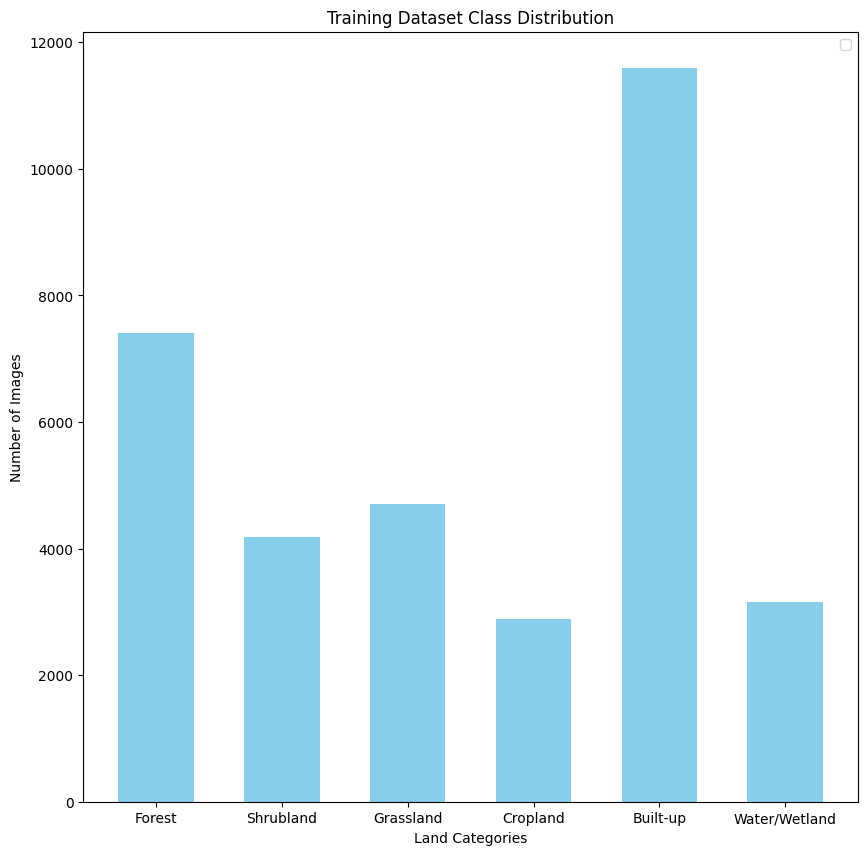

In [13]:
labels_mapping = {
    0:"Forest",
    1:"Shrubland",
    2:"Grassland",
    3:"Cropland",
    4:"Built-up",
    5:"Water/Wetland"
}

value_counts = train_df[label_col].value_counts().sort_index().to_list()
print(value_counts)
plt.figure(figsize=(10,10))
plt.bar(labels_mapping.values(),value_counts, color='skyblue',width=0.6)
plt.xlabel("Land Categories")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")
plt.legend()
plt.show()

In [14]:
print("TRAIN IMAGES")
print(train_images.shape)
print(train_images.dtype)
print(train_images.min(), train_images.max())

print("\nTEST IMAGES")
print(test_images.shape)
print(test_images.dtype)
print(test_images.min(), test_images.max())

print("\nTRAIN CSV")
print(train_df.shape)
print(train_df.columns.tolist())
print(train_df.head())

print("\nTEST CSV")
print(test_df.shape)
print(test_df.columns.tolist())
print(test_df.head())

TRAIN IMAGES
(33939, 4, 64, 64)
uint8
22 255

TEST IMAGES
(9891, 4, 64, 64)
uint8
18 255

TRAIN CSV
(33939, 2)
['Id', 'label']
                  Id  label
0  GEO_R01_1984_1280      4
1  GEO_R01_0640_0000      4
2  GEO_R01_0896_2112      4
3  GEO_R01_1440_0928      4
4  GEO_R01_1856_2112      4

TEST CSV
(9891, 1)
['Id']
                  Id
0  GEO_R14_1728_1504
1  GEO_R14_0128_0480
2  GEO_R14_1824_0032
3  GEO_R14_2016_0032
4  GEO_R14_0800_0096


### Extraction of the Regions which is there in the current data
Here is the analysis where you will extract the data out for the purpose of analysing how imbalanced the data is.

Current structure of the image file is: GEO_R14_####_####

We are interested in the "R##", where the hash represent the number. We can infer that different number represent different regions which is being extracted.

In [15]:
train_df["regions"] = train_df["Id"].str.extract(r"(R\d+)")
test_df["regions"] = test_df["Id"].str.extract(r"(R\d+)")

#Training Regions
print("Training Regions")
print(train_df['regions'].value_counts().sort_index())

#Testing Regions
print("Testing Regions")
print(train_df['regions'].value_counts().sort_index())

Training Regions
regions
R01    5893
R02    2245
R03    4943
R04    1159
R05    1733
R06    6202
R07    1476
R08    1512
R09    1243
R10     601
R11    1477
R12    3336
R13       2
R18    2117
Name: count, dtype: int64
Testing Regions
regions
R01    5893
R02    2245
R03    4943
R04    1159
R05    1733
R06    6202
R07    1476
R08    1512
R09    1243
R10     601
R11    1477
R12    3336
R13       2
R18    2117
Name: count, dtype: int64


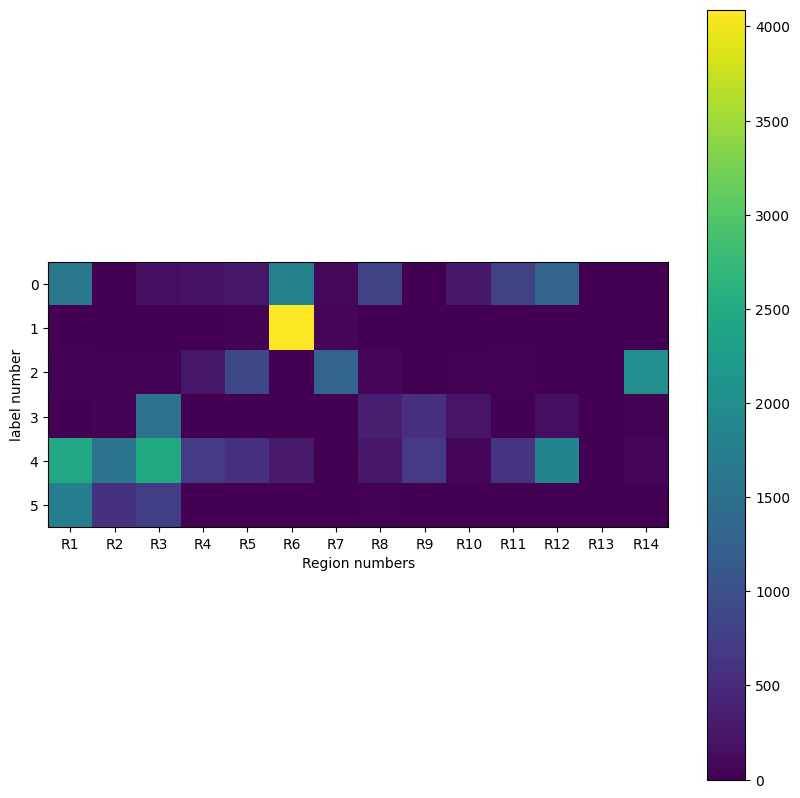

In [17]:
#We group and see the classification and through regions
region_class = pd.crosstab(train_df['label'],train_df['regions'])
plt.figure(figsize=(10,10))
plt.imshow(region_class,cmap = 'viridis',interpolation='nearest')
plt.colorbar()
plt.xlabel('Region numbers')
plt.ylabel('label number')
num_cols = len(train_df['regions'].unique())
custom_labels = [f"R{i}" for i in range(1, num_cols + 1)]
plt.xticks(ticks=np.arange(num_cols), labels=custom_labels)
plt.show()

This will plot 4 layers(Blue, Green, Red, NIR) of the 10 image

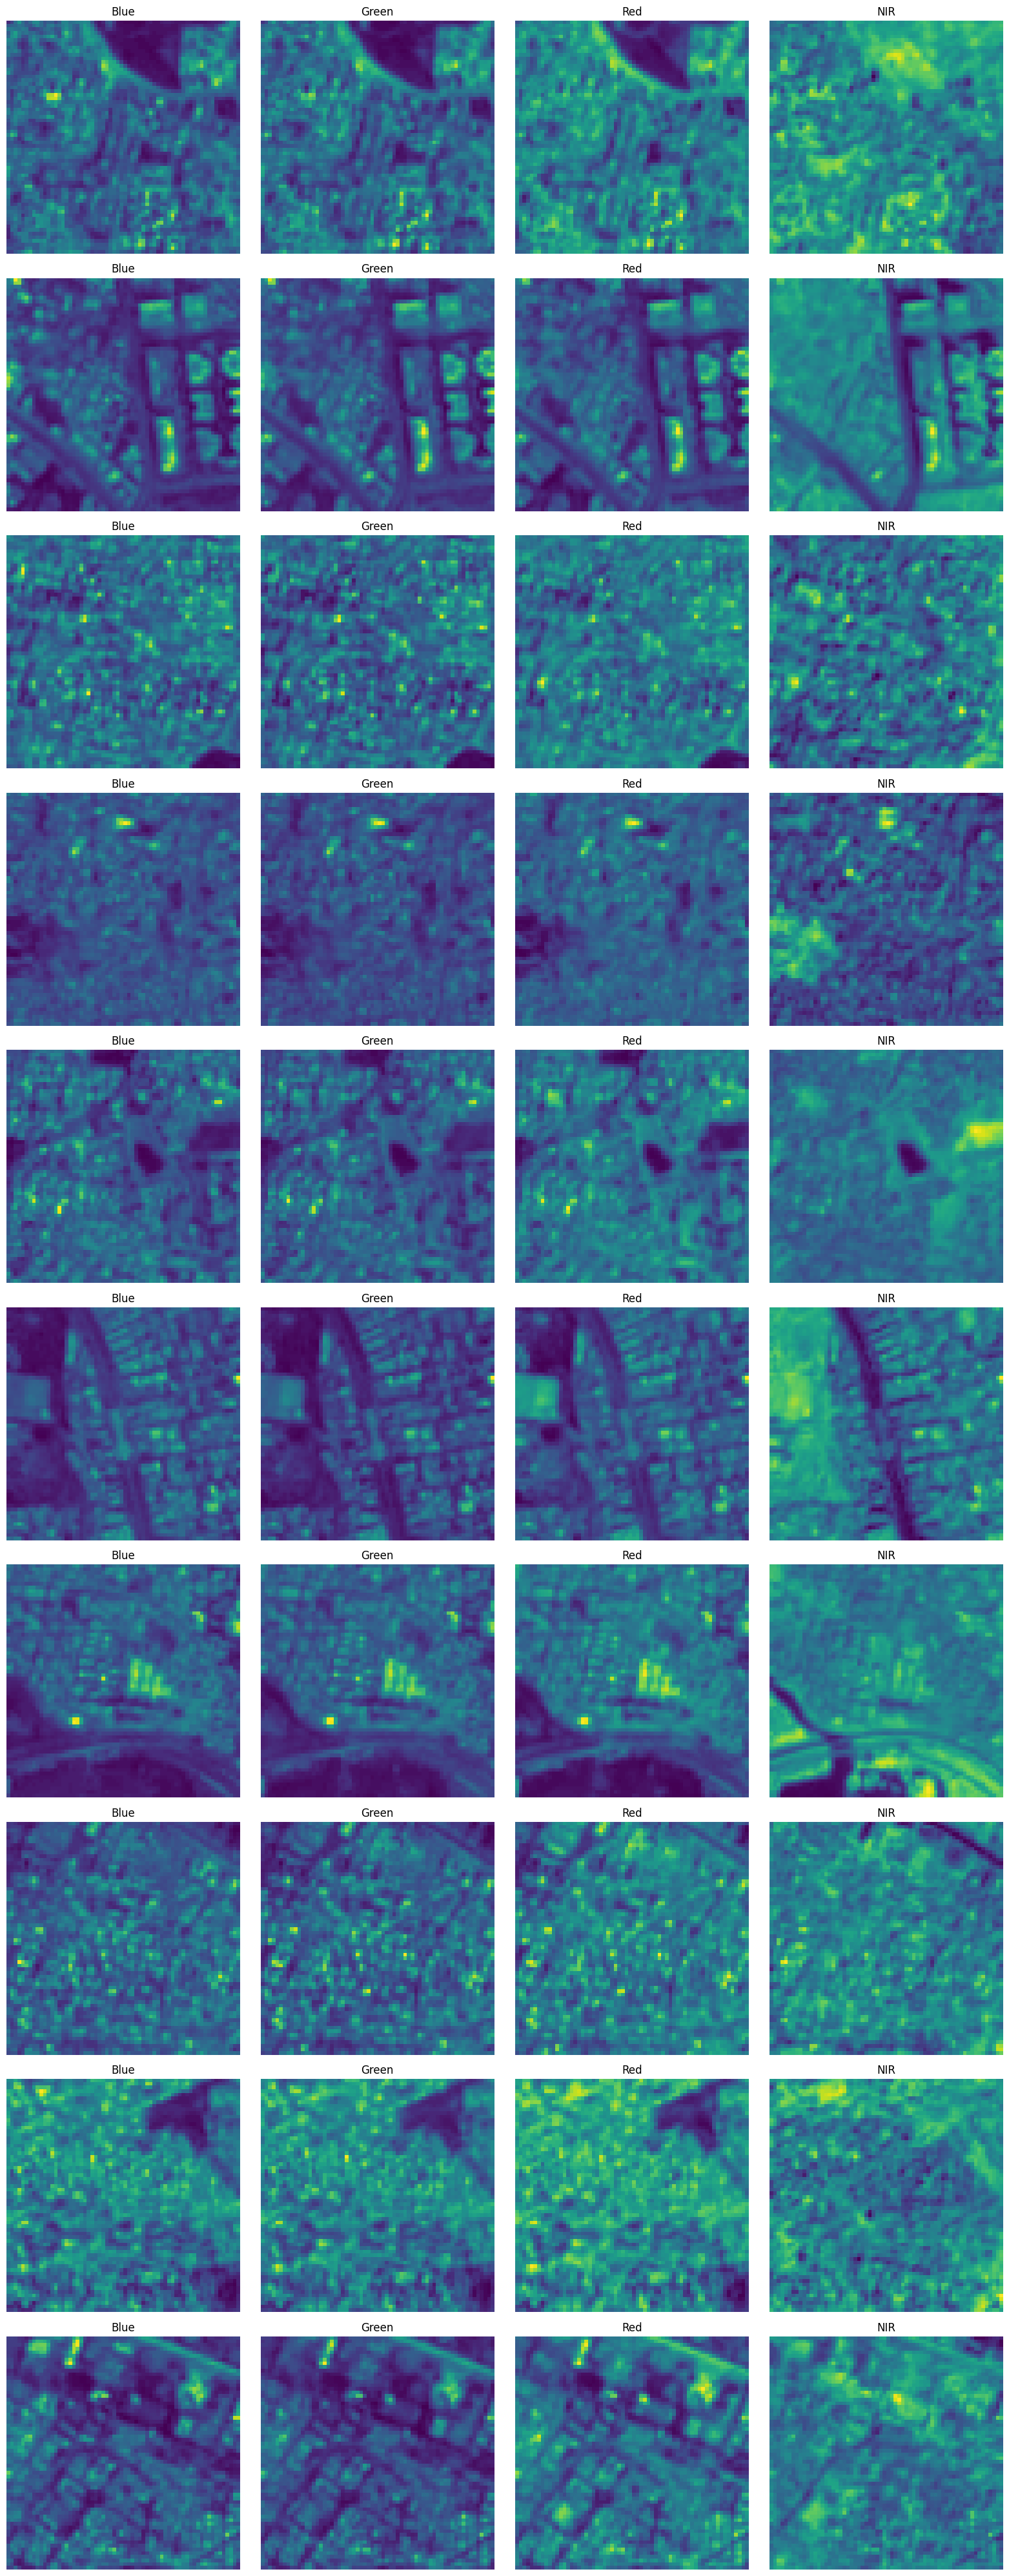

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 4, figsize=(16, 40))
for j in range(10):
    for i, name in enumerate(["Blue", "Green", "Red", "NIR"]):
        axes[j][i].imshow(train_images[j][i])
        axes[j][i].set_title(name)
        axes[j][i].axis("off")

plt.tight_layout()
plt.show()